# Sliding window Analysis 

In [6]:
import xarray as xr 
import numpy as np 
import pandas as pd
from importlib import reload 
import matplotlib.pyplot as plt
import plotting as pl 
import anomaly_and_clustering as ac 
import sliding_window as sw
import xskillscore as xs
import sliding_window_tele_analysis as sa

In [ ]:
seas5_u10_u100 = xr.open_dataset("C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/SEAS5_processed/SEAS5_zonal_mean_zonal_wind_10_100hpa_1981_2025.nc", engine='netcdf4',decode_timedelta=False).drop_vars(['latitude'])
era5_nino34_daily_index = xr.open_dataset("C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/ERA5_processed/ERA5_NINO34_daily_NDJFM_clim_NDJ_1940_2025.nc", engine='netcdf4', decode_timedelta=False)
seas5_nino34_daily_index = xr.open_dataset("C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/SEAS5_processed/SEAS5_NINO34_daily_NDJFM_clim_NDJ_1981_2025.nc", engine='netcdf4', decode_timedelta=False)
era5_u10_u100 = xr.open_dataset("C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/ERA5_processed/ERA5_ZMZW_1940_2025.nc", engine='netcdf4',decode_timedelta=False)
era5_clusters = xr.open_dataset("C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/ERA5_SEAS5_Anomaly_and_Clustering/Clustering_and_EOF_Analysis/ERA5_6_clusters_1940_2025_DJFM_daily_clim_linear_detrend_anomaly.nc", engine='netcdf4',decode_timedelta=False)
seas5_clusters = xr.open_dataset("C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/ERA5_SEAS5_Anomaly_and_Clustering/Clustering_and_EOF_Analysis/SEAS5_6_clusters_1981_2025_assigned_from_ERA5_1940_2025_DJFM_daily_clim_linear_detrend_anomaly.nc", engine='netcdf4',decode_timedelta=False)
era5_eof = xr.open_dataset("C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/ERA5_SEAS5_Anomaly_and_Clustering/Clustering_and_EOF_Analysis/ERA5_EOF_z500_1940_2025_DJFM_daily_clim_linear_detrend_anomaly.nc", engine='netcdf4',decode_timedelta=False)
seas5_eof = xr.open_dataset("C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/ERA5_SEAS5_Anomaly_and_Clustering/Clustering_and_EOF_Analysis/SEAS5_EOF_z500_1981_2025_from_ERA5_1940_2025_DJFM_daily_clim_linear_detrend_anomaly.nc", engine='netcdf4',decode_timedelta=False)


## compute ENSO NJF mean and broadcast to daily time

In [ ]:
era5_enso_index=era5_nino34_daily_index.sst
seas5_enso_index=seas5_nino34_daily_index.sst

seas5_enso_index_ndj_mean = seas5_enso_index.sel(step=slice(0,91*24)).mean(dim='step')
seas5_enso_index_ndj_mean_daily = seas5_enso_index_ndj_mean.sel(time=seas5_enso_index.time)
seas5_enso_index_ndj_mean_daily = seas5_enso_index_ndj_mean_daily.expand_dims(step = seas5_enso_index.step).transpose("time","number","step")
seas5_enso_index_ndj_mean_daily

era5 = era5_enso_index.assign_coords(
    winter_year=xr.where(
        era5_enso_index.time.dt.month <= 3,
        era5_enso_index.time.dt.year - 1,
        era5_enso_index.time.dt.year
    )
)

ndj_mean = (
    era5
    .where(era5.time.dt.month.isin([11, 12, 1]), drop=True)
    .groupby("winter_year")
    .mean("time")
)

ndjfm_mask = era5_enso_index.time.dt.month.isin([11, 12, 1, 2, 3])

winter_year = era5.winter_year

era5_enso_index_ndj_daily = ndj_mean.sel(
    winter_year=winter_year
).where(ndjfm_mask)
era5_enso_index_ndj_daily

In [ ]:
reload(ac)
spv_lag_days = 0

DJF_steps = np.arange(720,3624, 24)
spv_lag_steps = DJF_steps - 24*spv_lag_days

valid_time_DJF = seas5_u10_u100.sel(step=DJF_steps).valid_time
valid_time_SPV_lagged = seas5_u10_u100.sel(step=spv_lag_steps).valid_time
seas5_u10_lagged = seas5_u10_u100.sel(isobaricInhPa=10).sel(step=spv_lag_steps).drop_vars(['isobaricInhPa'])
seas5_clusters_DJF = seas5_clusters.sel(step=DJF_steps)


era5_u10 = era5_u10_u100.u.sel(isobaricInhPa = 10)
era5_u10 = era5_u10.drop_vars(['number','isobaricInhPa','step','valid_time','latitude'])

seas5_spv_lagged = ac.compute_ensemble_zscore_variable(seas5_u10_lagged,'u')
era5_spv = ac.compute_reanalysis_zscore_variable(era5_u10_u100.sel(isobaricInhPa = 10),'u')
era5_spv = era5_spv.drop_vars(['number','isobaricInhPa','step','valid_time','latitude'])

In [ ]:
linear_detrend_cluster_order = [2,0,3,5,1,4]
fixed_cluster_order = [2,1,4,5,3,0]
cluster_names = ['NAO+','NAO-','AR-','AR+','SB-','SB+']
window_size = 15

sliding_window_results = sw.compute_sliding_window_means(
    era5_clusters,
    seas5_clusters_DJF,
    era5_eof.scores,
    seas5_eof.scores,
    era5_u10,
    seas5_u10_lagged.u,
    era5_spv,
    seas5_spv_lagged,
    era5_enso_index_ndj_daily,
    seas5_enso_index_ndj_mean_daily,
    era5_cluster_order=linear_detrend_cluster_order,
    seas5_cluster_order=linear_detrend_cluster_order,
    cluster_names=cluster_names,
    window_size=window_size,
    extended=False
)

sliding_window_results

In [ ]:
sliding_window_results.drop_attrs().to_netcdf(f'C:/Users/rc831063/ONEDRI~1/PhD/Data/ERA5_SEAS5_Anomaly_and_Clustering/Segmentation_Stats/SEAS5_1981_2025_and_ERA5_1940_2025_DJFM_daily_clim_linear_detrend_anomaly_{window_size}d_sliding_window_mean_ndj_enso_spv_{spv_lag_days}d_lagged.nc')


In [2]:
sliding_window_results = xr.open_dataset("C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/ERA5_S~2/SEGMEN~1/SEAS5_1981_2025_and_ERA5_1940_2025_DJFM_daily_clim_linear_detrend_anomaly_21d_sliding_window_mean_ndj_enso_spv_0d_lagged.nc", engine='netcdf4',decode_timedelta=False)
# "C:\Users\rc831063\OneDrive - University of Reading\PhD\Data\ERA5_S~2\SEGMEN~1\EXTEND~3.NC"
cluster_order = [2,1,4,5,3,0]
cluster_names = ['NAO+','NAO-','AR-','AR+','SB-','SB+']

print(sliding_window_results)

<xarray.Dataset> Size: 64MB
Dimensions:           (cluster: 6, time: 44, number: 51, window: 101, mode: 14)
Coordinates:
  * cluster           (cluster) <U4 96B 'NAO+' 'NAO-' 'AR-' 'AR+' 'SB-' 'SB+'
  * time              (time) datetime64[ns] 352B 1981-11-01 ... 2024-11-01
  * number            (number) int32 204B 0 1 2 3 4 5 6 ... 44 45 46 47 48 49 50
  * window            (window) <U5 2kB '12-11' '12-12' ... '03-20' '03-21'
    step              (window) float64 808B ...
    winter_year       (time, window) int64 36kB ...
  * mode              (mode) int64 112B 1 2 3 4 5 6 7 8 9 10 11 12 13 14
    isobaricInhPa     float64 8B ...
    surface           float64 8B ...
Data variables: (12/16)
    seas5_frequency   (cluster, time, number, window) float64 11MB ...
    era5_frequency    (cluster, time, window) float64 213kB ...
    seas5_projection  (time, number, window, cluster) float64 11MB ...
    era5_projection   (time, window, cluster) float64 213kB ...
    seas5_index       (time, 

# Skill

In [4]:
corr = xs.pearson_r(sliding_window_results['era5_projection'], sliding_window_results['seas5_projection'].mean(dim='number'), dim='time')
beta = xs.linslope(sliding_window_results['seas5_projection'].mean(dim='number'),sliding_window_results['era5_projection'], dim='time')
sig = xs.pearson_r_p_value(sliding_window_results['era5_projection'], sliding_window_results['seas5_projection'].mean(dim='number'), dim='time')
sig_mask = sig < 0.05

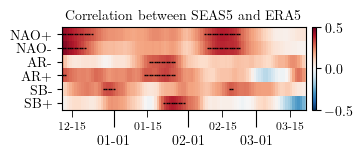

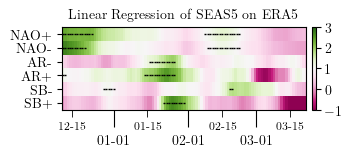

In [5]:
reload(sw)
file_path = "C:/Users/rc831063/OneDrive - University of Reading/PhD/Figures/Segmentation Analysis/Sliding Window Analysis/Mediation/Lagged_SPV_NDJ_ENSO/pooledv2/0d_lagged_SPV_ndj_ENSO_"
sw.plot_skill_window_heatmaps(
    data=corr,
    sig=sig_mask,
    cluster_names=cluster_names,
    skill="corr",
    dataset_name="Correlation between SEAS5 and ERA5",
    file_path=None,
    window_size = 15
)

sw.plot_skill_window_heatmaps(
    data=beta,
    sig=sig_mask,
    cluster_names=cluster_names,
    skill="beta",
    dataset_name="Linear Regression of SEAS5 on ERA5",
    file_path=None,
    window_size = 15
)

# Causal network analysis

In [7]:
reload(sa)
seas5_med_results = sa.run_pooled_bootstrap_mediation_mean(
    sliding_window_results,
    y_var="seas5_projection",
    x_var="seas5_enso",
    m_var="seas5_u10",
    n_boot=2000,
    seed=42
)

era5_med_results = sa.run_pooled_bootstrap_mediation_mean(
    sliding_window_results,
    y_var="era5_projection",
    x_var="era5_enso",
    m_var="era5_u10",
    n_boot=2000,
    seed=42
)

Clusters: 100%|██████████| 6/6 [00:02<00:00,  2.09it/s]


In [8]:
reload(sa)
seas5_memberwise = sa.run_member_sampling_mediation(
    sliding_window_results,
    y_var="seas5_projection",
    x_var="seas5_enso",
    m_var="seas5_u10",
    n_iterations=2000,
    seed=42
)

Clusters: 100%|██████████| 6/6 [00:02<00:00,  2.16it/s]


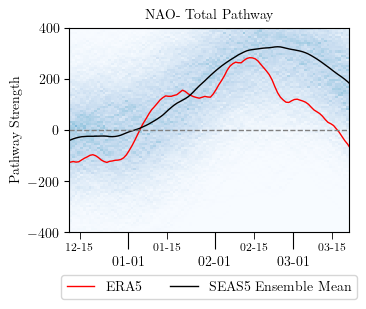

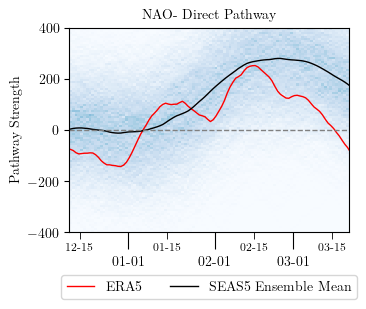

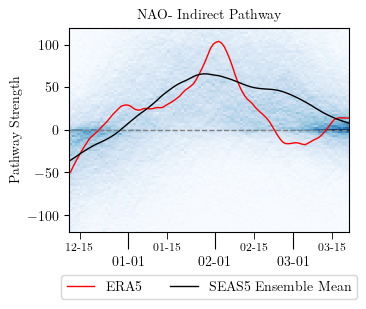

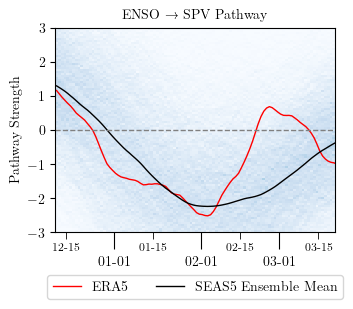

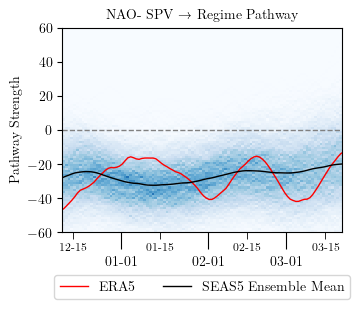

In [9]:
reload(sw)

sw.plot_memberwise_pathways(seas5_memberwise, seas5_med_results, era5_med_results)

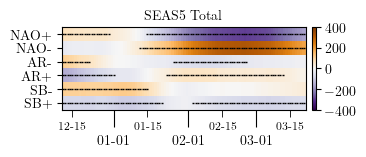

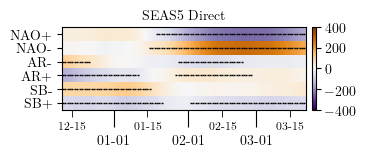

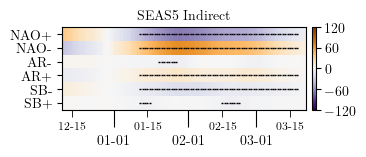

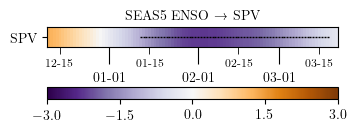

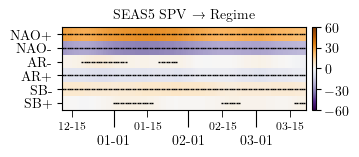

In [11]:
reload(sw)
file_path = 'C:/Users/rc831063/OneDrive - University of Reading/PhD/Figures/Segmentation Analysis/Sliding Window Analysis/Mediation/Lagged_SPV_NDJ_ENSO/0d_lagged_SPV_ndj_ENSO_'
sw.plot_mediation_window_heatmaps(
    dataset=seas5_med_results,
    cluster_names=cluster_names,
    dataset_name="SEAS5",
    file_path=None,
    window_size = 21
)